# Baseline Experiment: Comparison of supervised and unsupervised CAE

This notebook evaluates only the **baseline experiment**.

It compares the unsupervised and supervised CAE by their performance on the reconstruction and classification task.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH = "../results/raw_results.json"

sns.set(style="whitegrid")

with open(PATH, "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Keep only relevant columns
df = df[[
    "dataset",
    "subset",
    "reconstruction_mse",
    "accuracy"
]]

df_grouped = (
    df
    .groupby(["dataset", "subset"])
    .agg({
        "accuracy": ["mean", "std"],
        "reconstruction_mse": ["mean", "std"]
    })
    .reset_index()
)

# Flatten column names
df_grouped.columns = [
    "dataset", "subset",
    "accuracy_mean", "accuracy_std",
    "reconstruction_mse_mean", "reconstruction_mse_std"
]

## Table Classification Accuracy

In [2]:
classification_table = df_grouped.pivot(
    index="dataset",
    columns="subset",
    values=["accuracy_mean", "accuracy_std"]
)

# Format as "mean ± std"
formatted_table = pd.DataFrame(index=classification_table.index)

for subset in ["unsupervised_cae", "supervised_cae"]:
    formatted_table[subset] = (
        classification_table["accuracy_mean"][subset].round(4).astype(str)
        + " ± "
        + classification_table["accuracy_std"][subset].round(4).astype(str)
    )

# Optional: nicer column names
formatted_table.columns = ["Unsupervised CAE", "Supervised CAE"]

print("\n=== Classification Accuracy (mean ± std) ===")
print(formatted_table)


=== Classification Accuracy (mean ± std) ===
              Unsupervised CAE   Supervised CAE
dataset                                        
activity       0.9063 ± 0.0213  0.9213 ± 0.0112
coil20          0.491 ± 0.0155  0.4997 ± 0.0227
fashion_mnist  0.7957 ± 0.0028  0.8043 ± 0.0023
isolet          0.8028 ± 0.021  0.8433 ± 0.0113
mice_protein   0.5972 ± 0.0877  0.6306 ± 0.0902
mnist          0.8649 ± 0.0051  0.8736 ± 0.0038


## Table Regression Error

In [3]:
reconstruction_table = df_grouped.pivot(
    index="dataset",
    columns="subset",
    values=["reconstruction_mse_mean", "reconstruction_mse_std"]
)

formatted_table = pd.DataFrame(index=reconstruction_table.index)

for subset in ["unsupervised_cae", "supervised_cae"]:
    formatted_table[subset] = (
        reconstruction_table["reconstruction_mse_mean"][subset].round(4).astype(str)
        + " ± "
        + reconstruction_table["reconstruction_mse_std"][subset].round(4).astype(str)
    )

# Optional nicer names
formatted_table.columns = ["Unsupervised CAE", "Supervised CAE"]

print("\n=== Reconstruction MSE (mean ± std) ===")
print(formatted_table)


=== Reconstruction MSE (mean ± std) ===
              Unsupervised CAE           Supervised CAE
dataset                                                
activity       0.2753 ± 0.0083          0.4459 ± 0.0333
coil20         0.4851 ± 0.1521  3290096.0 ± 341274.7415
fashion_mnist  0.0194 ± 0.0003          0.0224 ± 0.0004
isolet         0.4062 ± 0.0078           0.485 ± 0.0148
mice_protein   0.4442 ± 0.0286          0.4255 ± 0.0428
mnist          0.0194 ± 0.0002          0.0236 ± 0.0004


## Plot Classification Accuracy

/var/folders/2d/rgh939n56knbdhv7tklttl740000gn/T/ipykernel_69087/3957006599.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


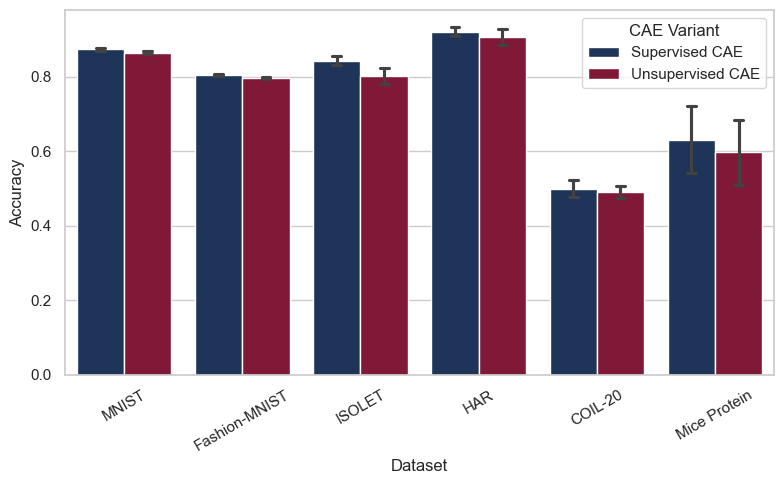

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset order
dataset_order = [
    "mnist",
    "fashion_mnist",
    "isolet",
    "activity",
    "coil20",
    "mice_protein",
]

dataset_labels = {
    "mnist": "MNIST",
    "fashion_mnist": "Fashion-MNIST",
    "isolet": "ISOLET",
    "activity": "HAR",
    "coil20": "COIL-20",
    "mice_protein": "Mice Protein",
}

palette = {
    "unsupervised_cae": "#910730",
    "supervised_cae": "#153163",
}

label_map = {
    "unsupervised_cae": "Unsupervised CAE",
    "supervised_cae": "Supervised CAE",
}

# Apply ordering
df_plot = df.copy()

df_plot["dataset"] = pd.Categorical(
    df_plot["dataset"],
    categories=dataset_order,
    ordered=True,
)

df_plot = df_plot.sort_values("dataset")

# Plot
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_plot,
    x="dataset",
    y="accuracy",
    hue="subset",
    order=dataset_order,
    palette=palette,
    errorbar="sd",   # standard deviation
    capsize=0.15
)

# Pretty x labels
ax.set_xticklabels(
    [dataset_labels[d] for d in dataset_order],
    rotation=30
)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map[l] for l in labels],
    title="CAE Variant"
)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Dataset")

plt.tight_layout()
plt.show()

## Plot Reconstruction Error

/var/folders/2d/rgh939n56knbdhv7tklttl740000gn/T/ipykernel_69087/3867377068.py:30: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  df_plot["dataset"] = pd.Categorical(
/var/folders/2d/rgh939n56knbdhv7tklttl740000gn/T/ipykernel_69087/3867377068.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


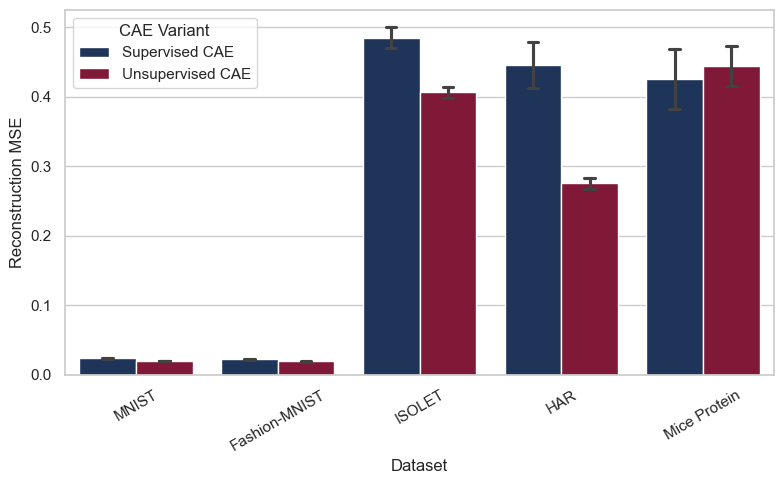

In [6]:
# Remove COIL-20
df_plot = df[df["dataset"] != "coil20"].copy()

dataset_order = [
    "mnist",
    "fashion_mnist",
    "isolet",
    "activity",
    "mice_protein",
]

dataset_labels = {
    "mnist": "MNIST",
    "fashion_mnist": "Fashion-MNIST",
    "isolet": "ISOLET",
    "activity": "HAR",
    "mice_protein": "Mice Protein",
}

palette = {
    "unsupervised_cae": "#910730",
    "supervised_cae": "#153163",
}

label_map = {
    "unsupervised_cae": "Unsupervised CAE",
    "supervised_cae": "Supervised CAE",
}

df_plot["dataset"] = pd.Categorical(
    df_plot["dataset"],
    categories=dataset_order,
    ordered=True,
)

df_plot = df_plot.sort_values("dataset")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_plot,
    x="dataset",
    y="reconstruction_mse",
    hue="subset",
    order=dataset_order,
    palette=palette,
    errorbar="sd",
    capsize=0.15,
)

ax.set_xticklabels(
    [dataset_labels[d] for d in dataset_order],
    rotation=30,
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map[l] for l in labels],
    title="CAE Variant",
)

ax.set_ylabel("Reconstruction MSE")
ax.set_xlabel("Dataset")

plt.tight_layout()
plt.show()